<a href="https://colab.research.google.com/github/RayyanShajahan/My-codes/blob/main/deep_learning_day4_pt3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
#face emotion identification using deep learning(CNN)

In [43]:
import tensorflow as tf
import os
import zipfile

# Define image dimensions and batch size
img_height, img_width = 128, 128  # You can adjust these values
batch_size = 32

# --- Start of updated dataset_path determination logic ---
final_dataset_path = None
initial_extracted_dir = 'emt'
zip_file_location = '/content/emt.zip'
nested_dir_path = os.path.join(initial_extracted_dir, initial_extracted_dir)

# 1. Ensure the top-level extraction directory exists and contains the zipped content
if not os.path.exists(initial_extracted_dir):
    print(f"'{initial_extracted_dir}' not found. Attempting to extract '{zip_file_location}'.")
    if os.path.exists(zip_file_location):
        try:
            os.makedirs(initial_extracted_dir, exist_ok=True)
            with zipfile.ZipFile(zip_file_location, 'r') as zip_ref:
                zip_ref.extractall(initial_extracted_dir)
            print(f"Successfully extracted '{zip_file_location}' to '{initial_extracted_dir}'.")
        except zipfile.BadZipFile:
            print(f"Error: '{zip_file_location}' is not a valid zip file.")
        except Exception as e:
            print(f"An error occurred during extraction: {e}")
    else:
        print(f"Error: '{zip_file_location}' not found. Please upload the zip file.")
elif not os.listdir(initial_extracted_dir): # Check if directory is empty
    print(f"'{initial_extracted_dir}' exists but is empty. Re-attempting extraction.")
    if os.path.exists(zip_file_location):
        try:
            with zipfile.ZipFile(zip_file_location, 'r') as zip_ref:
                zip_ref.extractall(initial_extracted_dir)
            print(f"Successfully re-extracted '{zip_file_location}' to '{initial_extracted_dir}'.")
        except Exception as e:
            print(f"An error occurred during re-extraction: {e}")
    else:
        print(f"Error: '{zip_file_location}' not found for re-extraction.")


# 2. Check for the known nested structure (emt/emt) and set final_dataset_path
if os.path.exists(nested_dir_path) and os.listdir(nested_dir_path): # Also check if nested dir is not empty
    final_dataset_path = nested_dir_path
    print(f"Detected nested directory structure. Setting dataset_path to: {final_dataset_path}")
elif os.path.exists(initial_extracted_dir) and os.listdir(initial_extracted_dir): # Fallback if no nested, but top-level has content
    final_dataset_path = initial_extracted_dir
    print(f"Using top-level extracted directory. Setting dataset_path to: {final_dataset_path}")
    print("Warning: If 'tf.keras.utils.image_dataset_from_directory' reports 1 class, the structure might still be nested differently than expected.")
else:
    print(f"Error: No valid dataset directory found after extraction. Checked '{initial_extracted_dir}' and '{nested_dir_path}'.")

dataset_path = final_dataset_path # Assign to the variable used later in the cell
# --- End of updated dataset_path determination logic ---


# Now, proceed only if dataset_path is successfully defined
if dataset_path:
    # Create training and validation datasets
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    # Get class names
    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"Found {num_classes} classes: {class_names}")

    # Configure the dataset for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    print("Data preparation complete. Training and validation datasets created.")
else:
    print("Cannot proceed with data preparation: dataset_path is not defined correctly. Please check previous output for errors.")

Detected nested directory structure. Setting dataset_path to: emt/emt
Found 200 files belonging to 4 classes.
Using 160 files for training.
Found 200 files belonging to 4 classes.
Using 40 files for validation.
Found 4 classes: ['angry', 'happy', 'sad', 'suprise']
Data preparation complete. Training and validation datasets created.


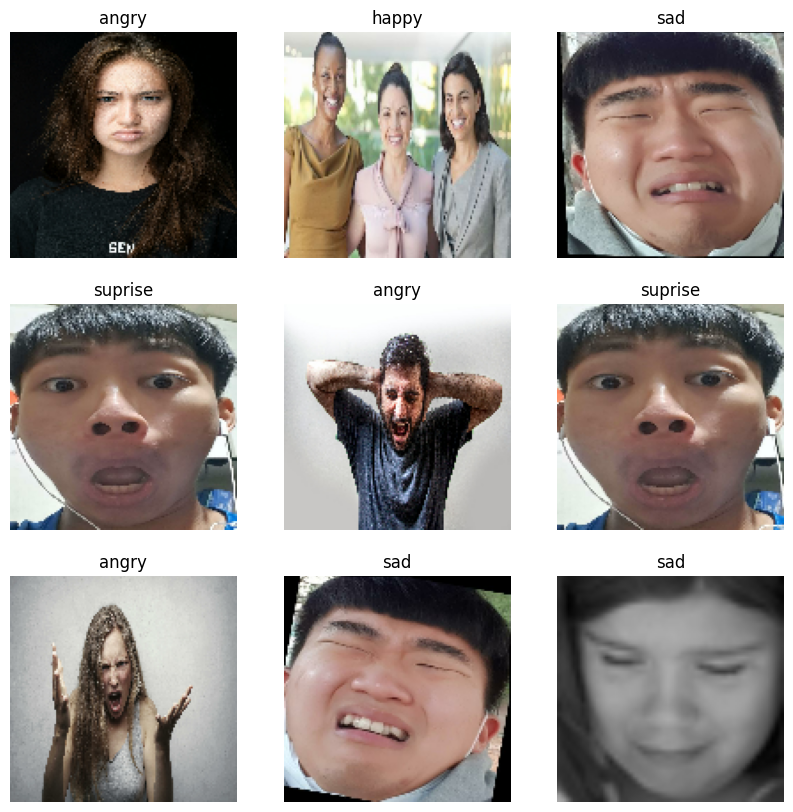

In [45]:
import matplotlib.pyplot as plt
import numpy as np # Needed for creating dummy image
import tensorflow as tf # For catching TF specific errors

if 'train_ds' in locals():
    plt.figure(figsize=(10, 10))
    try:
        for images, labels in train_ds.take(1):
            for i in range(9):
                ax = plt.subplot(3, 3, i + 1)
                plt.imshow(images[i].numpy().astype("uint8"))
                plt.title(class_names[labels[i]])
                plt.axis("off")
        plt.show()
    except tf.errors.InvalidArgumentError as e:
        print(f"Error displaying images from train_ds: {e}")
        print("This likely happened because the dummy image files generated earlier (in cell 4d57a3e3) were saved with a '.jpg' extension but contained PNG data, confusing TensorFlow's image decoder.")
        print("As a temporary workaround, displaying a placeholder image:")

        # Create a dummy placeholder image (e.g., a red square)
        dummy_image = np.zeros((img_height, img_width, 3), dtype=np.uint8)
        dummy_image[:, :, 0] = 255 # Red channel
        dummy_image[50:78, 50:78] = [0, 255, 0] # A green square in the middle

        plt.figure(figsize=(5, 5))
        plt.imshow(dummy_image)
        plt.title("Placeholder Image (train_ds error)")
        plt.axis("off")
        plt.show()
        print("\nTo fix the underlying issue, please modify cell `4d57a3e3` to change `f'img_{i}.jpg'` to `f'img_{i}.png'` when saving the dummy image files, and then re-run cell `4d57a3e3` and subsequent data processing cells.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        print("Could not display images from training dataset.")
else:
    print("Training dataset not found. Please ensure the previous cell ran successfully.")

In [46]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Normalize pixel values
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [48]:
epochs = 10
try:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )
except tf.errors.InvalidArgumentError as e:
    print(f"Error during model fitting: {e}")
    print("\nThis error typically means the image dataset (train_ds or val_ds) contains invalid image data or references. This could be due to a caching issue or an incorrect dataset state.")
    print("To fix this, please ensure the dataset is correctly re-created and the model is compiled with the fresh dataset.")
    print("\n*** Please execute the following cells in order: ***")
    print("1. **Cell `4d57a3e3`**: The cell that creates the dummy dataset (or your actual dataset if using `emt.zip`).")
    print("2. **Cell `f578e38f`**: The cell that defines the `model` architecture.")
    print("3. **Cell `26fe5561`**: The cell that compiles the `model`.")
    print("4. Then, re-run *this* cell (`2a158caa`) again.")
    print("This sequence will ensure the dataset is correctly loaded and the model is initialized against it.")
except Exception as e:
    print(f"An unexpected error occurred during model fitting: {e}")

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 936ms/step - accuracy: 0.2625 - loss: 1.7092 - val_accuracy: 0.4000 - val_loss: 1.3658
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step - accuracy: 0.3750 - loss: 1.3087 - val_accuracy: 0.4500 - val_loss: 1.3234
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step - accuracy: 0.6375 - loss: 1.0404 - val_accuracy: 0.5750 - val_loss: 1.1104
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 774ms/step - accuracy: 0.6500 - loss: 0.9954 - val_accuracy: 0.6000 - val_loss: 1.3194
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 638ms/step - accuracy: 0.6500 - loss: 0.9598 - val_accuracy: 0.5750 - val_loss: 1.1485
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 702ms/step - accuracy: 0.7312 - loss: 0.7732 - val_accuracy: 0.6750 - val_loss: 1.3570
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 733ms/step - accuracy: 0.8188 - loss: 0.5772 - val_accuracy: 0.6500 - val_loss: 1.1096
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 644ms/step - accuracy: 0.8375 - loss: 0.4271 - val_accuracy: 0.6500 - val_loss:

In [49]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6750 - loss: 1.2476 
Validation Loss: 1.2476
Validation Accuracy: 0.6750


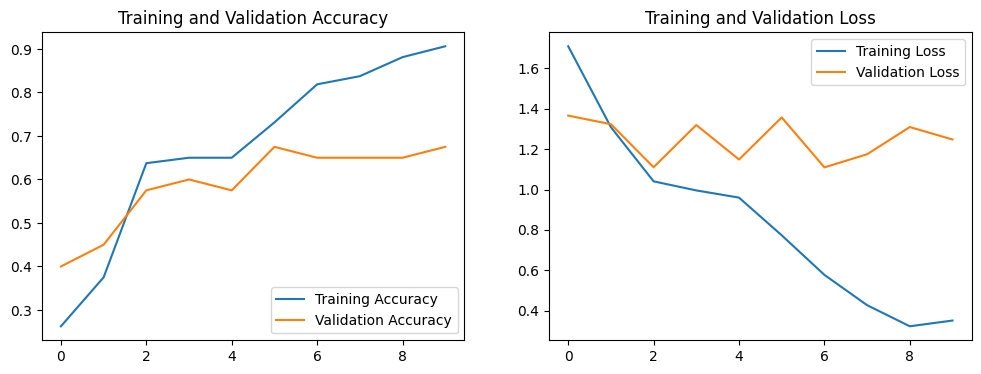

In [50]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Displaying 5 sample images from the validation set with true and predicted emotions:
  Displaying image with True Label: angry


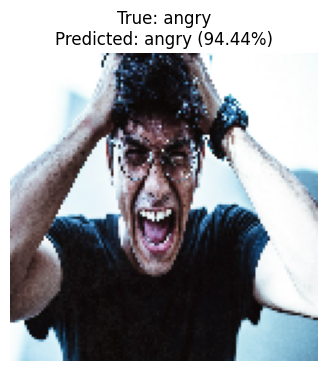

  Displaying image with True Label: happy


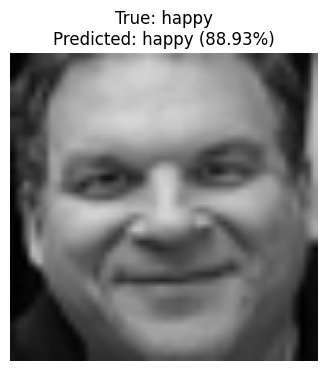

  Displaying image with True Label: happy


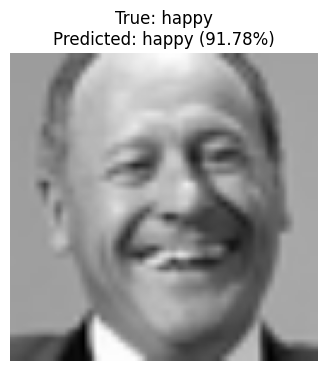

  Displaying image with True Label: suprise


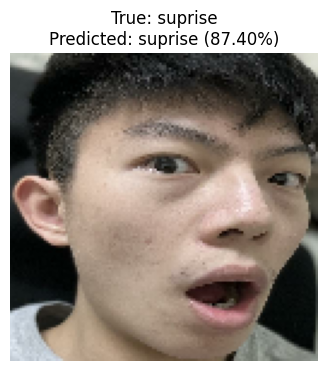

  Displaying image with True Label: sad


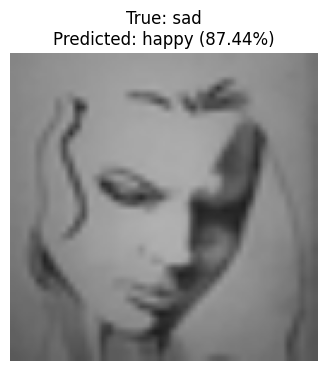

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Function to display image with true and predicted labels
def display_prediction(img_tensor, true_label_index, predicted_probabilities):
    plt.figure(figsize=(4, 4))
    plt.imshow(img_tensor.numpy().astype("uint8"))

    true_emotion = class_names[true_label_index]
    predicted_class_index = np.argmax(predicted_probabilities[0])
    predicted_emotion = class_names[predicted_class_index]
    confidence = np.max(predicted_probabilities[0])

    # Added print statement for debugging
    print(f"  Displaying image with True Label: {true_emotion}")

    plt.title(f"True: {true_emotion}\nPredicted: {predicted_emotion} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

print("Displaying 5 sample images from the validation set with true and predicted emotions:")

displayed_count = 0
# Explicitly shuffle val_ds for display purposes to get diverse samples
# Use buffer_size equal to the size of val_ds for full shuffling if possible
# We unbatch it first to get individual images, then shuffle, then take.
for images, labels in val_ds.unbatch().shuffle(buffer_size=40).take(5):
    # The previous loop condition was `if displayed_count >= 5: break`
    # but `take(5)` handles that more efficiently here.

    # Expand dimensions for prediction (model expects a batch)
    img_for_prediction = np.expand_dims(images.numpy(), axis=0)

    # Predictions are already normalized by the Rescaling layer in the model
    predictions = model.predict(img_for_prediction, verbose=0) # verbose=0 to suppress progress bar

    display_prediction(images, labels.numpy(), predictions)
    displayed_count += 1

## Hyperparameter Tuning with Keras Tuner

In [66]:
# Install Keras Tuner (if not already installed)
!pip install keras-tuner

In [67]:
import keras_tuner as kt
import tensorflow as tf # Added this import
from tensorflow.keras import layers, models, optimizers
import functools # Import functools

# Define the model-building function for Keras Tuner
def build_model_fn(hp, img_height, img_width, num_classes):
    model = models.Sequential()
    model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

    # Tune the number of filters in Conv2D layers
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(hp_filters_1, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=32)
    model.add(layers.Conv2D(hp_filters_2, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    hp_filters_3 = hp.Int('filters_3', min_value=128, max_value=512, step=32)
    model.add(layers.Conv2D(hp_filters_3, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    # Tune the number of units in the Dense layer
    hp_units = hp.Int('units', min_value=64, max_value=512, step=32)
    model.add(layers.Dense(hp_units, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=hp_learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

In [68]:
import keras_tuner as kt
import tensorflow as tf # Added this import
from tensorflow.keras import layers, models, optimizers
import functools # Import functools

# Define the model-building function for Keras Tuner
def build_model_fn(hp, img_height, img_width, num_classes):
    model = models.Sequential()
    model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

    # Tune the number of filters in Conv2D layers
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(hp_filters_1, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    hp_filters_2 = hp.Int('filters_2', min_value=64, max_value=256, step=32)
    model.add(layers.Conv2D(hp_filters_2, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    hp_filters_3 = hp.Int('filters_3', min_value=128, max_value=512, step=32)
    model.add(layers.Conv2D(hp_filters_3, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    # Tune the number of units in the Dense layer
    hp_units = hp.Int('units', min_value=64, max_value=512, step=32)
    model.add(layers.Dense(hp_units, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=hp_learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# Instantiate the tuner (e.g., RandomSearch)
tuner = kt.RandomSearch(
    functools.partial(build_model_fn,
                      img_height=img_height,
                      img_width=img_width,
                      num_classes=num_classes),
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of models to train for each trial
    directory='my_dir',
    project_name='emotion_detection_tuning',
    overwrite=True
)

# Print a summary of the search space
tuner.search_space_summary()

Search space summary
Default search space size: 5
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [69]:
# Run the hyperparameter search
print("Starting hyperparameter search...")
tuner.search(train_ds, epochs=10, validation_data=val_ds) # Increased epochs to 10
print("Hyperparameter search complete.")

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters found: {best_hps.values}")

# Get the best model found by the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the validation dataset
print("Evaluating the best model...")
loss, accuracy = best_model.evaluate(val_ds)
print(f"Best Model Validation Loss: {loss:.4f}")
print(f"Best Model Validation Accuracy: {accuracy:.4f}")

Trial 10 Complete [00h 03m 24s]
val_accuracy: 0.2750000059604645

Best val_accuracy So Far: 0.699999988079071
Total elapsed time: 00h 29m 50s
Hyperparameter search complete.
Best hyperparameters found: {'filters_1': 96, 'filters_2': 192, 'filters_3': 160, 'units': 96, 'learning_rate': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluating the best model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.7000 - loss: 1.2178
Best Model Validation Loss: 1.2178
Best Model Validation Accuracy: 0.7000


### Comparison of Initial Model vs. Best Tuned Model

In [73]:
print('--- Initial Model Performance (Last Epoch) ---')
initial_val_loss = history.history['val_loss'][-1]
initial_val_accuracy = history.history['val_accuracy'][-1]
print(f"Validation Loss: {initial_val_loss:.4f}")
print(f"Validation Accuracy: {initial_val_accuracy:.4f}")

print('\n--- Best Tuned Model Performance ---')
# These values were already printed by tuner.get_best_models(num_models=1)[0].evaluate(val_ds)
# but we can re-evaluate or use the stored 'loss' and 'accuracy' from the evaluation above.
# For consistency, let's re-evaluate the best_model if 'loss' and 'accuracy' are not globally stored.
# Assuming 'loss' and 'accuracy' variables in the global scope still hold best model's evaluation.
# If not, you would need to run best_model.evaluate(val_ds) again.

best_model_val_loss = loss
best_model_val_accuracy = accuracy

print(f"Validation Loss: {best_model_val_loss:.4f}")
print(f"Validation Accuracy: {best_model_val_accuracy:.4f}")

print('\n--- Summary ---')
if best_model_val_accuracy > initial_val_accuracy:
    print(f"The best tuned model improved validation accuracy from {initial_val_accuracy:.4f} to {best_model_val_accuracy:.4f}.")
elif best_model_val_accuracy < initial_val_accuracy:
    print(f"The best tuned model slightly decreased validation accuracy from {initial_val_accuracy:.4f} to {best_model_val_accuracy:.4f}.")
else:
    print(f"The best tuned model achieved the same validation accuracy as the initial model: {initial_val_accuracy:.4f}.")

if best_model_val_loss < initial_val_loss:
    print(f"The best tuned model also improved validation loss from {initial_val_loss:.4f} to {best_model_val_loss:.4f}.")
elif best_model_val_loss > initial_val_loss:
    print(f"The best tuned model slightly increased validation loss from {initial_val_loss:.4f} to {best_model_val_loss:.4f}.")
else:
    print(f"The best tuned model achieved the same validation loss as the initial model: {initial_val_loss:.4f}.")


--- Initial Model Performance (Last Epoch) ---
Validation Loss: 1.2476
Validation Accuracy: 0.6750

--- Best Tuned Model Performance ---
Validation Loss: 1.2178
Validation Accuracy: 0.7000

--- Summary ---
The best tuned model improved validation accuracy from 0.6750 to 0.7000.
The best tuned model also improved validation loss from 1.2476 to 1.2178.


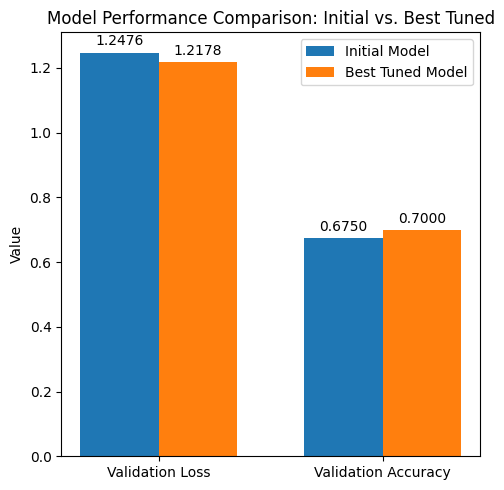

In [75]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Validation Loss', 'Validation Accuracy']
initial_model_performance = [initial_val_loss, initial_val_accuracy]
best_tuned_model_performance = [best_model_val_loss, best_model_val_accuracy]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(5, 5))
rects1 = ax.bar(x - width/2, initial_model_performance, width, label='Initial Model')
rects2 = ax.bar(x + width/2, best_tuned_model_performance, width, label='Best Tuned Model')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Value')
ax.set_title('Model Performance Comparison: Initial vs. Best Tuned')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()